# 1. Setup — Environment & Dependencies

In [127]:
# Create an isolated environment (you know this pattern from your Docker experience —
# same idea, just Python-level instead of container-level)
!python -m venv yolo_env
!source yolo_env/bin/activate  # on Windows: yolo_env\Scripts\activate

!pip install ultralytics roboflow supervision opencv-python matplotlib albumentations

Error: Command '['/kaggle/working/yolo_env/bin/python3', '-m', 'ensurepip', '--upgrade', '--default-pip']' returned non-zero exit status 1.
/bin/bash: line 1: yolo_env/bin/activate: No such file or directory


In [128]:
# Download YOLOv12 nano pretrained weights (2.6M params — small, fast, good for a laptop/Colab GPU)
! wget https://github.com/ultralytics/assets/releases/download/v8.4.0/yolo12n.pt

--2026-09-10 06:53:43--  https://github.com/ultralytics/assets/releases/download/v8.4.0/yolo12n.pt
Resolving github.com (github.com)... 140.82.114.3
Connecting to github.com (github.com)|140.82.114.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://release-assets.githubusercontent.com/github-production-release-asset/521807533/25ab588f-21ac-44b7-93dc-0defead21c92?sp=r&sv=2018-11-09&sr=b&spr=https&se=2026-09-10T07%3A42%3A00Z&rscd=attachment%3B+filename%3Dyolo12n.pt&rsct=application%2Foctet-stream&skoid=96c2d410-5711-43a1-aedd-ab1947aa7ab0&sktid=398a6654-997b-47e9-b12b-9515b896b4de&skt=2026-09-10T06%3A41%3A37Z&ske=2026-09-10T07%3A42%3A00Z&sks=b&skv=2018-11-09&sig=9D6XUQIeo7ev8xcOcvN0z68lCYTDg3owskxK0Nfy%2Brg%3D&jwt=eyJ0eXAiOiJKV1QiLCJhbGciOiJIUzI1NiJ9.eyJpc3MiOiJnaXRodWIuY29tIiwiYXVkIjoicmVsZWFzZS1hc3NldHMuZ2l0aHVidXNlcmNvbnRlbnQuY29tIiwia2V5Ijoia2V5MSIsImV4cCI6MTc4OTAyMzUyMywibmJmIjoxNzg5MDIzMjIzLCJwYXRoIjoicmVsZWFzZWFzc2V0cHJvZHVjdGlvbi5ibG9iLmNvcmU

In [129]:
import os
import json
import random
import shutil
from collections import Counter, defaultdict
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import yaml
from PIL import Image
import imagehash

from roboflow import Roboflow
from ultralytics import YOLO
from ultralytics.utils.metrics import box_iou


# 2. Load & Sanity-Check the Pretrained Model

In [130]:
model = YOLO('yolo12n.pt')
print(model.model)  # prints the architecture — worth skimming once so it's not a black box

DetectionModel(
  (model): Sequential(
    (0): Conv(
      (conv): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (bn): BatchNorm2d(16, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
      (act): SiLU(inplace=True)
    )
    (1): Conv(
      (conv): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
      (act): SiLU(inplace=True)
    )
    (2): C3k2(
      (cv1): Conv(
        (conv): Conv2d(32, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (cv2): Conv(
        (conv): Conv2d(48, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn): BatchNorm2d(64, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
   

# 3. Download & Prepare the Dataset (Roboflow)

In [131]:
# dataset.py

# NOTE: don't leave a real API key hardcoded in a notebook you'll submit/share —
# use an environment variable instead, e.g.:
# rf = Roboflow(api_key=os.environ["ROBOFLOW_API_KEY"])
rf = Roboflow(api_key="w2eDCZvatuxW3ZFwAoDU")  # from roboflow.com account settings
 
project = rf.workspace("nani-tmzf6").project("package-detection-5ozpr")
version = project.version(2)
dataset = version.download("yolov8")  # format name; YOLOv12 uses the same label format as v8/v11

project2 = rf.workspace("damaged-package").project("damaged-package")
version2 = project2.version(2)
dataset2 = version2.download("yolov8")

print(f"Dataset location: {dataset.location}")
print(f"Dataset2 location: {dataset2.location}")

loading Roboflow workspace...
loading Roboflow project...
loading Roboflow workspace...
loading Roboflow project...
Dataset location: /kaggle/working/package-detection-2
Dataset2 location: /kaggle/working/Damaged-package-2


In [132]:

with open(f'{dataset.location}/data.yaml') as f:
    data = yaml.safe_load(f)

# Keep this as the single source of truth for class names/order everywhere below,
# instead of re-typing ['damaged', 'no damaged'] by hand in later cells — if Roboflow's
# class order doesn't match what you assume, every downstream metric/label is silently wrong.
CLASS_NAMES = data['names']
print(CLASS_NAMES)


['damaged', 'no damaged']


In [133]:

with open(f'{dataset2.location}/data.yaml') as f:
    data = yaml.safe_load(f)

# Keep this as the single source of truth for class names/order everywhere below,
# instead of re-typing ['damaged', 'no damaged'] by hand in later cells — if Roboflow's
# class order doesn't match what you assume, every downstream metric/label is silently wrong.
CLASS_NAMES = data['names']
print(CLASS_NAMES)


['Damaged', 'Destroyed', 'Intact']


In [134]:

def remove_augmented_files(dataset_location, split='train'):
    img_dir = f'{dataset_location}/{split}/images'
    label_dir = f'{dataset_location}/{split}/labels'
    removed = 0

    for fname in os.listdir(img_dir):
        if '_aug' in fname:
            os.remove(os.path.join(img_dir, fname))
            removed += 1

    for fname in os.listdir(label_dir):
        if '_aug' in fname:
            os.remove(os.path.join(label_dir, fname))

    print(f"Removed {removed} augmented image/label pairs")
    return removed

remove_augmented_files(dataset.location)

Removed 0 augmented image/label pairs


0

## 3.1 Class Balance Check

In [135]:

def check_class_balance(dataset_location, split='train'):
    label_dir = f'{dataset_location}/{split}/labels'
    counts = Counter()
    for fname in os.listdir(label_dir):
        if not fname.endswith('.txt'):
            continue
        with open(os.path.join(label_dir, fname)) as f:
            for line in f:
                cls = int(float(line.strip().split()[0]))  # normalize "0", "0.0" -> 0
                counts[cls] += 1
    print(f"{split} set box counts: {dict(counts)}")
    return counts
print("DataSet 1:")
check_class_balance(dataset.location, 'train')
check_class_balance(dataset.location, 'valid')
check_class_balance(dataset.location, 'test')
train_counts = check_class_balance(dataset.location, 'train')
minority_class = min(train_counts, key=train_counts.get)
print(f"Minority class id: {minority_class}")
print("###########################################")
print ("DataSet 2:")
check_class_balance(dataset2.location, 'train')
check_class_balance(dataset2.location, 'valid')
check_class_balance(dataset2.location, 'test')
train_counts = check_class_balance(dataset2.location, 'train')
minority_class = min(train_counts, key=train_counts.get)
print(f"Minority class id: {minority_class}")

DataSet 1:
train set box counts: {0: 1169, 1: 1025}
valid set box counts: {0: 358, 1: 84}
test set box counts: {0: 220, 1: 65}
train set box counts: {0: 1169, 1: 1025}
Minority class id: 1
###########################################
DataSet 2:
train set box counts: {0: 294, 2: 782, 1: 75}
valid set box counts: {1: 12, 0: 20, 2: 2}
test set box counts: {0: 16, 2: 38, 1: 5}
train set box counts: {0: 294, 2: 782, 1: 75}
Minority class id: 1


## Merging 2 Datasets

In [136]:

def remap_and_merge_intact_only(new_dataset_location, target_location, split='train'):
    """Pull only the Intact-labeled images from the new dataset, remap them to
    class 1 ('no damaged'), and copy into the target dataset's matching split."""
    src_img_dir = f'{new_dataset_location}/{split}/images'
    src_lbl_dir = f'{new_dataset_location}/{split}/labels'
    dst_img_dir = f'{target_location}/{split}/images'
    dst_lbl_dir = f'{target_location}/{split}/labels'

    copied = 0
    for fname in os.listdir(src_lbl_dir):
        if not fname.endswith('.txt'):
            continue
        with open(os.path.join(src_lbl_dir, fname)) as f:
            lines = [l.split() for l in f if l.strip()]

        # keep only boxes that are class 2 (Intact) in the source dataset
        intact_lines = [l for l in lines if int(float(l[0])) == 2]
        if not intact_lines:
            continue  # skip images with no Intact boxes at all

        stem = fname.rsplit('.', 1)[0]
        for ext in ('.jpg', '.jpeg', '.png'):
            src_img = f'{src_img_dir}/{stem}{ext}'
            if os.path.exists(src_img):
                new_name = f'merged_{stem}{ext}'
                shutil.copy(src_img, f'{dst_img_dir}/{new_name}')
                with open(f'{dst_lbl_dir}/merged_{stem}.txt', 'w') as f:
                    for l in intact_lines:
                        # remap class 2 -> 1 ('no damaged'), keep original box coords
                        f.write(f"1 {' '.join(l[1:])}\n")
                copied += 1
                break

    print(f"[{split}] Copied {copied} real Intact images as 'no damaged'")
    return copied

# 1. remove old synthetic augmentation first
remove_augmented_files(dataset.location, 'train')

# 2. merge real intact images across all splits
for split in ('train', 'valid', 'test'):
    remap_and_merge_intact_only(dataset2.location, dataset.location, split)

# 3. confirm new balance
check_class_balance(dataset.location, 'train')
check_class_balance(dataset.location, 'valid')
check_class_balance(dataset.location, 'test')

Removed 0 augmented image/label pairs
[train] Copied 66 real Intact images as 'no damaged'
[valid] Copied 2 real Intact images as 'no damaged'
[test] Copied 4 real Intact images as 'no damaged'
train set box counts: {0: 1169, 1: 1026}
valid set box counts: {0: 358, 1: 84}
test set box counts: {0: 220, 1: 65}


Counter({0: 220, 1: 65})

## 3.3 Deleting duplicates

In [137]:
!pip install ImageHash

In [138]:
import os
from collections import defaultdict
from PIL import Image
import imagehash

def find_near_duplicates(dataset_location, splits=('train', 'valid', 'test'), threshold=5):
    hashes = {}
    for split in splits:
        img_dir = f'{dataset_location}/{split}/images'
        if not os.path.isdir(img_dir):
            continue
        for fname in sorted(os.listdir(img_dir)):  # sorted = deterministic order
            try:
                h = imagehash.phash(Image.open(os.path.join(img_dir, fname)))
                hashes[(split, fname)] = h
            except Exception:
                continue

    items = list(hashes.items())
    visited = set()
    groups = []

    for i, ((split1, fname1), h1) in enumerate(items):
        if (split1, fname1) in visited:
            continue
        group = [(split1, fname1)]
        for (split2, fname2), h2 in items[i+1:]:
            if (split2, fname2) in visited:
                continue
            if (h1 - h2) <= threshold:  # compare directly against h1 only, no chaining
                group.append((split2, fname2))
                visited.add((split2, fname2))
        if len(group) > 1:  # duplicate found, regardless of split
            groups.append(group)
            visited.add((split1, fname1))

    print(f"Duplicate groups found (any split): {len(groups)}")
    for g in groups[:10]:
        print("  ", g)
    return groups


# val/test are small and must stay clean, so they always win.
# Priority: test > valid > train. Whichever split has the lowest priority
# number in a group is kept; everything else in that group is removed.
SPLIT_PRIORITY = {'test': 0, 'valid': 1, 'train': 2}

def remove_near_duplicates(dataset_location, groups):
    removed = 0
    for group in groups:
        keep = min(group, key=lambda item: SPLIT_PRIORITY.get(item[0], 99))
        for split, fname in group:
            if (split, fname) == keep:
                continue
            for sub, ext in [('images', None), ('labels', '.txt')]:
                path = f'{dataset_location}/{split}/{sub}/{fname if not ext else fname.rsplit(".",1)[0]+ext}'
                if os.path.exists(path):
                    os.remove(path)
            removed += 1
    print(f"Removed {removed} near-duplicate files")
    return removed


# run it
near_dups = find_near_duplicates(dataset.location)
remove_near_duplicates(dataset.location, near_dups)

Duplicate groups found (any split): 208
   [('train', '-_-20210307_230302_jpg.rf.beb3d5c5cf602be47f65fd2142ad4cbe.jpg'), ('train', '-_-20210307_230302_jpg.rf.fc000da71e5af65fa038d8bae6c5d93f.jpg')]
   [('train', '054e373ee27f3162bc27247bd341555b_jpeg_jpg.rf.e4b295023c220fa6d71b587a6e60863e.jpg'), ('train', 'images-13-_jpg.rf.de728ea9aff65c52951f7eebe525f93b.jpg'), ('train', 'images-136-_jpg.rf.7cb9d6006c47796d5bf13061292f2ae0.jpg')]
   [('train', '0RHQReXVH8Nbv4_jpg.rf.380f754fc5dee0ca72c4bed3d160cb27.jpg'), ('train', '0RHQReXVH8Nbv4_jpg.rf.a90203c3b38846728c234eb3cc5792f4.jpg')]
   [('train', '11830601_ig1uW6Bw9EJOdvuzPrdRIVHVMgq99SnEbwjB0M9lGP8_jpg.rf.0d36bed29f2233d088be6a9a622f135d.jpg'), ('train', '11830601_ig1uW6Bw9EJOdvuzPrdRIVHVMgq99SnEbwjB0M9lGP8_jpg.rf.1c90d4f41a29327773398e0384faf01c.jpg'), ('train', '11830601_ig1uW6Bw9EJOdvuzPrdRIVHVMgq99SnEbwjB0M9lGP8_jpg.rf.4f3825f400d57e0aa3216b2f44cdabeb.jpg'), ('train', '11830601_ig1uW6Bw9EJOdvuzPrdRIVHVMgq99SnEbwjB0M9lGP8_jpg.rf.9fa77

261

## Respliting with a fixed ratio

In [139]:

def pool_and_resplit(dataset_location, train_ratio=0.7, valid_ratio=0.15, seed=42):
    """Combine all images across current train/valid/test into one pool,
    then re-split with consistent class ratios in each split."""
    random.seed(seed)

    # 1. gather every image+label pair currently in the dataset, tagged by its classes
    all_items = []
    for split in ('train', 'valid', 'test'):
        img_dir = f'{dataset_location}/{split}/images'
        lbl_dir = f'{dataset_location}/{split}/labels'
        if not os.path.isdir(img_dir):
            continue
        for fname in os.listdir(img_dir):
            stem = fname.rsplit('.', 1)[0]
            lbl_path = f'{lbl_dir}/{stem}.txt'
            if not os.path.exists(lbl_path):
                continue
            with open(lbl_path) as f:
                classes = set(int(float(l.split()[0])) for l in f if l.strip())
            all_items.append((split, fname, stem, classes))

    print(f"Total pooled images: {len(all_items)}")

    # 2. stratify by whether the image contains class 1 ('no damaged'), so both
    #    splits get proportional representation of the minority-heavier class
    has_class1 = [item for item in all_items if 1 in item[3]]
    no_class1 = [item for item in all_items if 1 not in item[3]]
    random.shuffle(has_class1)
    random.shuffle(no_class1)

    def split_group(group):
        n = len(group)
        n_train = int(n * train_ratio)
        n_valid = int(n * valid_ratio)
        return group[:n_train], group[n_train:n_train+n_valid], group[n_train+n_valid:]

    train1, valid1, test1 = split_group(has_class1)
    train0, valid0, test0 = split_group(no_class1)

    new_assignment = {}
    for group, name in [(train1+train0, 'train'), (valid1+valid0, 'valid'), (test1+test0, 'test')]:
        for old_split, fname, stem, _ in group:
            new_assignment[(old_split, fname)] = (name, fname, stem)

    # 3. move files into a fresh directory structure
    out_base = f'{dataset_location}_resplit'
    for split in ('train', 'valid', 'test'):
        os.makedirs(f'{out_base}/{split}/images', exist_ok=True)
        os.makedirs(f'{out_base}/{split}/labels', exist_ok=True)

    for (old_split, fname), (new_split, fname2, stem) in new_assignment.items():
        src_img = f'{dataset_location}/{old_split}/images/{fname}'
        src_lbl = f'{dataset_location}/{old_split}/labels/{stem}.txt'
        shutil.copy(src_img, f'{out_base}/{new_split}/images/{fname}')
        shutil.copy(src_lbl, f'{out_base}/{new_split}/labels/{stem}.txt')

    print(f"Re-split dataset written to: {out_base}")
    return out_base

new_location = pool_and_resplit(dataset.location)
shutil.copy(f'{dataset.location}/data.yaml', f'{new_location}/data.yaml')

Total pooled images: 1881
Re-split dataset written to: /kaggle/working/package-detection-2_resplit


'/kaggle/working/package-detection-2_resplit/data.yaml'

## generating background crops

In [140]:
def generate_crops_as_negatives(dataset_location, split='train', n_crops=60, crop_size=(640, 640)):
    """Crop random regions from existing images, avoiding areas with a package,
    to use as background-only negative examples."""
    img_dir = f'{dataset_location}/{split}/images'
    lbl_dir = f'{dataset_location}/{split}/labels'
    out_dir = f'{dataset_location}/{split}/images'  # save alongside existing images

    fnames = [f for f in os.listdir(img_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    random.shuffle(fnames)

    added = 0
    for fname in fnames:
        if added >= n_crops:
            break
        stem = fname.rsplit('.', 1)[0]
        lbl_path = f'{lbl_dir}/{stem}.txt'
        if not os.path.exists(lbl_path):
            continue

        img = Image.open(f'{img_dir}/{fname}')
        w, h = img.size
        if w < crop_size[0] or h < crop_size[1]:
            continue

        # read existing boxes (normalized) to avoid cropping on top of them
        with open(lbl_path) as f:
            boxes = [list(map(float, l.split()[1:])) for l in f if l.strip()]

        # try a few random crop positions, keep the first one that avoids all boxes
        for _ in range(10):
            x0 = random.randint(0, w - crop_size[0])
            y0 = random.randint(0, h - crop_size[1])
            x1, y1 = x0 + crop_size[0], y0 + crop_size[1]
            crop_box_norm = (x0/w, y0/h, x1/w, y1/h)

            overlaps = False
            for bx, by, bw, bh in boxes:
                bx0, by0 = bx - bw/2, by - bh/2
                bx1, by1 = bx + bw/2, by + bh/2
                if not (bx1 < crop_box_norm[0] or bx0 > crop_box_norm[2] or
                        by1 < crop_box_norm[1] or by0 > crop_box_norm[3]):
                    overlaps = True
                    break

            if not overlaps:
                crop = img.crop((x0, y0, x1, y1))
                new_name = f'{stem}_bgcrop{added}.jpg'
                crop.save(f'{out_dir}/{new_name}')
                open(f'{lbl_dir}/{stem}_bgcrop{added}.txt', 'w').close()  # empty = no objects
                added += 1
                break

    print(f"Added {added} background-only crops to {split}")
    return added

generate_crops_as_negatives(new_location, split='train', n_crops=60)

Added 60 background-only crops to train


60

In [141]:
print(os.path.exists(f'{new_location}/data.yaml'))
check_class_balance(new_location, 'train')
check_class_balance(new_location, 'valid')
check_class_balance(new_location, 'test')

True
train set box counts: {0: 1545, 1: 1152}
valid set box counts: {0: 451, 1: 377}
test set box counts: {0: 459, 1: 452}


Counter({0: 459, 1: 452})

## Corrupt/unreadable image detection

In [142]:

def find_corrupt_images(dataset_location, splits=('train', 'valid', 'test')):
    corrupt = []
    for split in splits:
        img_dir = f'{dataset_location}/{split}/images'
        if not os.path.isdir(img_dir):
            continue
        for fname in os.listdir(img_dir):
            path = os.path.join(img_dir, fname)
            try:
                if os.path.getsize(path) == 0:
                    raise ValueError("zero-byte file")
                img = Image.open(path)
                img.verify()  # checks file integrity without fully decoding
            except Exception as e:
                corrupt.append((split, fname, str(e)))

    print(f"Corrupt/unreadable images found: {len(corrupt)}")
    for split, fname, err in corrupt:
        print(f"  {split}/{fname}: {err}")
    return corrupt

corrupt_files = find_corrupt_images(new_location)

# --- deletion, commented out — uncomment only if len(corrupt_files) is small enough to sanity check ---
# for split, fname, _ in corrupt_files:
#     img_path = f'{dataset.location}/{split}/images/{fname}'
#     label_path = f'{dataset.location}/{split}/labels/{fname.rsplit(".",1)[0]}.txt'
#     for p in (img_path, label_path):
#         if os.path.exists(p):
#             os.remove(p)
# print(f"Removed {len(corrupt_files)} corrupt image/label pairs")

Corrupt/unreadable images found: 0


## Label sanity check

In [143]:
def find_bad_labels(dataset_location, splits=('train', 'valid', 'test')):
    bad = []
    for split in splits:
        img_dir = f'{dataset_location}/{split}/images'
        label_dir = f'{dataset_location}/{split}/labels'
        if not os.path.isdir(label_dir):
            continue

        img_files = {f.rsplit('.', 1)[0] for f in os.listdir(img_dir)}
        label_files = {f.rsplit('.', 1)[0] for f in os.listdir(label_dir) if f.endswith('.txt')}

        # orphaned labels — .txt with no matching image
        for stem in label_files - img_files:
            bad.append((split, f'{stem}.txt', 'orphaned label, no matching image'))

        # malformed boxes inside existing label files
        for fname in os.listdir(label_dir):
            if not fname.endswith('.txt'):
                continue
            fpath = os.path.join(label_dir, fname)
            with open(fpath) as f:
                for line_num, line in enumerate(f, 1):
                    parts = line.strip().split()
                    if not parts:
                        continue
                    if len(parts) != 5:
                        bad.append((split, fname, f'line {line_num}: wrong number of values'))
                        continue
                    cls, xc, yc, bw, bh = parts
                    xc, yc, bw, bh = map(float, (xc, yc, bw, bh))
                    if bw <= 0 or bh <= 0:
                        bad.append((split, fname, f'line {line_num}: zero/negative width or height'))
                    if not (0 <= xc <= 1 and 0 <= yc <= 1 and 0 <= bw <= 1 and 0 <= bh <= 1):
                        bad.append((split, fname, f'line {line_num}: coordinate out of 0-1 range'))

    print(f"Label issues found: {len(bad)}")
    for split, fname, reason in bad[:15]:
        print(f"  {split}/{fname}: {reason}")
    return bad

bad_labels = find_bad_labels(new_location)

# deletion — removes the whole label file (and its image) if any issue was found in it
def remove_bad_labels(dataset_location, bad_labels):
    to_remove = {(split, fname) for split, fname, _ in bad_labels}
    removed = 0
    for split, fname in to_remove:
        stem = fname.rsplit('.', 1)[0]
        label_path = f'{dataset_location}/{split}/labels/{fname}'
        for ext in ('.jpg', '.jpeg', '.png'):
            img_path = f'{dataset_location}/{split}/images/{stem}{ext}'
            if os.path.exists(img_path):
                os.remove(img_path)
                break
        if os.path.exists(label_path):
            os.remove(label_path)
        removed += 1
    print(f"Removed {removed} image/label pairs with bad labels")
    return removed

# remove_bad_labels(dataset.location, bad_labels)  # uncomment once reviewed

Label issues found: 0


In [144]:
check_class_balance(new_location, 'train')
check_class_balance(new_location, 'valid')
check_class_balance(new_location, 'test')

train set box counts: {0: 1545, 1: 1152}
valid set box counts: {0: 451, 1: 377}
test set box counts: {0: 459, 1: 452}


Counter({0: 459, 1: 452})

# 4. Train YOLOv12

In [145]:
model = YOLO('yolo12n.pt')  # fresh weights — confirm this every time
results = model.train(
    data=f'{new_location}/data.yaml',
    epochs=80,
    imgsz=640,
    device='cuda',
    batch=16,
    workers=4,
    patience=15,
    close_mosaic=10,
    project='yolov12_package',
    name='package_detection'
)

Ultralytics 8.4.146 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/package-detection-2_resplit/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=80, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo12n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=package_detection-7, n

Traceback (most recent call last):
  File "/usr/lib/python3.12/multiprocessing/queues.py", line 259, in _feed
    reader_close()
  File "/usr/lib/python3.12/multiprocessing/connection.py", line 178, in close
    self._close()
  File "/usr/lib/python3.12/multiprocessing/connection.py", line 377, in _close
    _close(self._handle)
OSError: [Errno 9] Bad file descriptor


AMP: checks passed ✅
train: Fast image access ✅ (ping: 0.0±0.0 ms, read: 882.2±349.6 MB/s, size: 32.8 KB)
train: Scanning /kaggle/working/package-detection-2_resplit/train/labels... 2157 images, 244 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 2157/2157 1.1Kit/s 1.9s0.1s
train: New cache created: /kaggle/working/package-detection-2_resplit/train/labels.cache
albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, method='weighted_average', num_output_channels=3), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 219.9±96.4 MB/s, size: 35.5 KB)
val: Scanning /kaggle/working/package-detection-2_resplit/valid/labels... 595 images, 3 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 595/595 1.0Kit/s 0.6s<0.1s
val: New cache created: /kaggle/working/package-detection-2_resplit/valid/labels.cache
optimizer: 'optimizer=auto' found, ignoring 'lr0=0.01' and 'momentum=0.937' and determining best 'opti

In [146]:
best_weights_path = str(results.save_dir / 'weights' / 'best.pt')
print(f"Best weights at: {best_weights_path}")

Best weights at: /kaggle/working/runs/detect/yolov12_package/package_detection-7/weights/best.pt


# 5. Evaluate — mAP, Precision, Recall, F1

In [147]:
with open(f'{new_location}/data.yaml') as f:
    CLASS_NAMES = yaml.safe_load(f)['names']
print(CLASS_NAMES)

['damaged', 'no damaged']


In [148]:

def evaluate_model(dataset_location, weights_path, class_names, split='test'):
    """Single source of truth for all reported metrics. Also derives, per class,
    the confidence threshold that ultralytics itself used to get the best F1 —
    later cells reuse this threshold instead of a hardcoded conf=0.25, so that
    any manual error-checking stays consistent with the numbers printed here."""
    model = YOLO(weights_path)
    metrics = model.val(data=f'{dataset_location}/data.yaml', imgsz=640, split=split)

    print(f"{'='*50}")
    print(f"Overall mAP50: {metrics.box.map50:.4f}")
    print(f"Overall mAP50-95: {metrics.box.map:.4f}")
    print(f"{'='*50}\n")

    print("Per-class metrics:")
    for i, name in enumerate(class_names):
        p, r, f1, ap50 = metrics.box.p[i], metrics.box.r[i], metrics.box.f1[i], metrics.box.ap50[i]
        print(f"  {name}: P={p:.3f}  R={r:.3f}  F1={f1:.3f}  AP50={ap50:.3f}")

    mean_f1 = metrics.box.f1.mean()
    print(f"\nMean F1 across classes: {mean_f1:.4f}")

    # best-F1 confidence threshold per class, taken straight from the P/R/F1 curves
    # ultralytics computed internally — this is what recall/precision above are based on
    f1_curve, px = metrics.box.f1_curve, metrics.box.px
    best_conf = {i: float(px[np.argmax(f1_curve[i])]) for i in range(len(class_names))}
    print("\nBest-F1 confidence threshold per class (used later for error analysis):")
    for i, name in enumerate(class_names):
        print(f"  {name}: conf={best_conf[i]:.3f}")

    return metrics, best_conf

metrics, best_conf_per_class = evaluate_model(new_location, best_weights_path, CLASS_NAMES, split='test')

Ultralytics 8.4.146 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
YOLOv12n summary (fused): 159 layers, 2,557,118 parameters, 0 gradients, 7.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1157.1±775.7 MB/s, size: 53.6 KB)
val: Scanning /kaggle/working/package-detection-2_resplit/test/labels... 601 images, 2 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 601/601 1.1Kit/s 0.6s<0.1s
val: New cache created: /kaggle/working/package-detection-2_resplit/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 38/38 5.2it/s 7.3s0.2s
                   all        601        911      0.885      0.859      0.913      0.796
               damaged        454        459      0.976      0.984      0.993       0.95
            no damaged        148        452      0.794      0.735      0.834      0.642
Speed: 1.5ms preprocess, 5.7ms inference, 0.0ms loss, 1.0ms postprocess per image
Results saved to /kaggle/w

## 5.1 Confusion Matrix

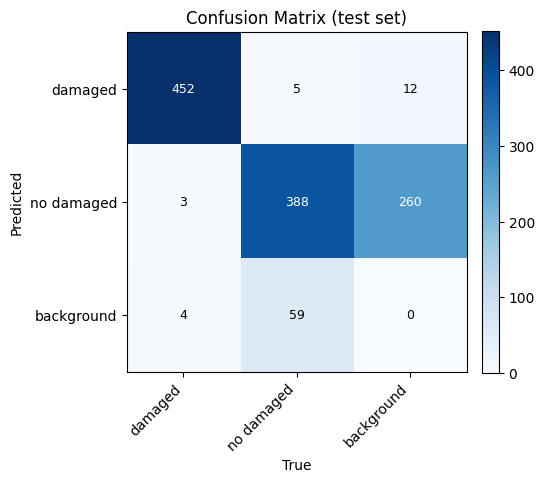

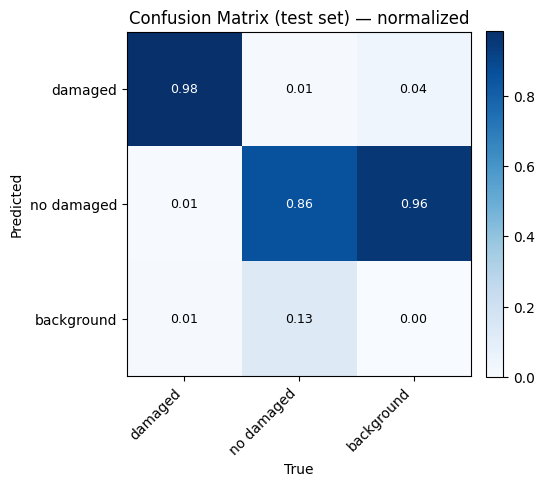

Raw counts (rows = predicted class, columns = true class, last row/col = background):
[[        452           5          12]
 [          3         388         260]
 [          4          59           0]]


In [149]:

def plot_confusion_matrix(metrics, class_names, normalize=False):
    """Ultralytics' ConfusionMatrix stores matrix[predicted_idx, true_idx], with an
    extra final row/col for 'background' (missed detections / spurious detections
    with no matching ground truth). We plot it directly rather than reconstructing
    it from predict() calls, so it's guaranteed to match metrics.box.p/r above."""
    cm = metrics.confusion_matrix.matrix.copy()
    labels = list(class_names) + ['background']

    if normalize:
        col_sums = cm.sum(axis=0, keepdims=True)
        col_sums[col_sums == 0] = 1
        cm = cm / col_sums

    fig, ax = plt.subplots(figsize=(5.5, 5))
    im = ax.imshow(cm, cmap='Blues')
    ax.set_xticks(range(len(labels))); ax.set_xticklabels(labels, rotation=45, ha='right')
    ax.set_yticks(range(len(labels))); ax.set_yticklabels(labels)
    ax.set_xlabel('True'); ax.set_ylabel('Predicted')
    ax.set_title('Confusion Matrix (test set)' + (' — normalized' if normalize else ''))

    vmax = cm.max() if cm.max() > 0 else 1
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            val = cm[i, j]
            text = f"{val:.2f}" if normalize else f"{int(val)}"
            ax.text(j, i, text, ha='center', va='center',
                     color='white' if val > vmax / 2 else 'black', fontsize=9)

    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()

plot_confusion_matrix(metrics, CLASS_NAMES, normalize=False)
plot_confusion_matrix(metrics, CLASS_NAMES, normalize=True)

print("Raw counts (rows = predicted class, columns = true class, last row/col = background):")
print(metrics.confusion_matrix.matrix)


## 5.2 Training Curves — Accuracy (mAP) & Loss

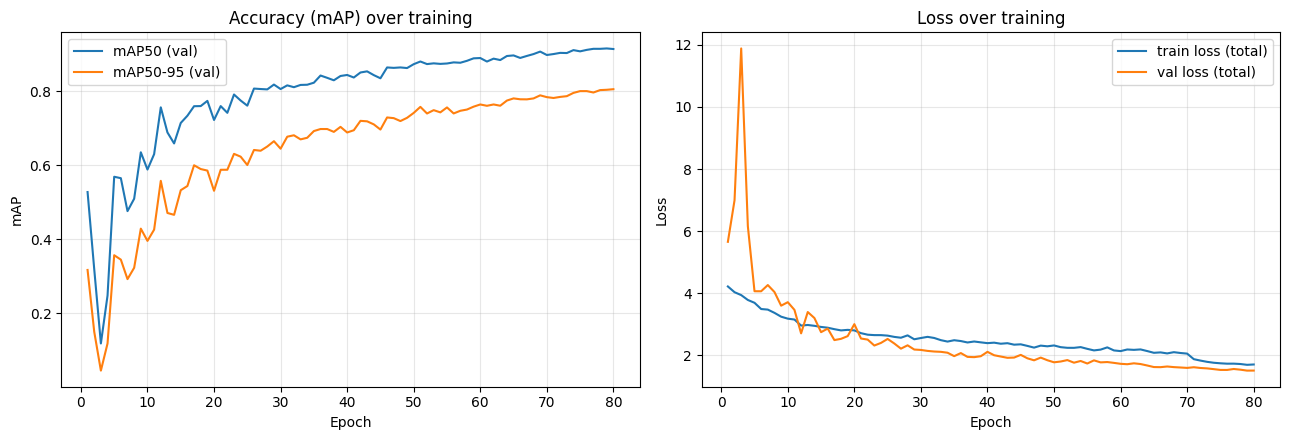

Final epoch (80):
  mAP50      = 0.9138
  mAP50-95   = 0.8052
  Train loss = 1.7025  (box=0.3490, cls=0.3293, dfl=1.0241)
  Val loss   = 1.5063  (box=0.3532, cls=0.2902, dfl=0.8630)


In [150]:

results_csv = f'{results.save_dir}/results.csv'
df = pd.read_csv(results_csv)
df.columns = df.columns.str.strip()

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Object detection has no single "accuracy" metric the way classification does —
# mAP50 (and mAP50-95) is the closest equivalent, so that's what we plot here.
axes[0].plot(df['epoch'], df['metrics/mAP50(B)'], label='mAP50 (val)')
axes[0].plot(df['epoch'], df['metrics/mAP50-95(B)'], label='mAP50-95 (val)')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('mAP')
axes[0].set_title('Accuracy (mAP) over training')
axes[0].legend(); axes[0].grid(alpha=0.3)

train_loss = df['train/box_loss'] + df['train/cls_loss'] + df['train/dfl_loss']
val_loss = df['val/box_loss'] + df['val/cls_loss'] + df['val/dfl_loss']
axes[1].plot(df['epoch'], train_loss, label='train loss (total)')
axes[1].plot(df['epoch'], val_loss, label='val loss (total)')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].set_title('Loss over training')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Final (last-epoch) values, printed explicitly as requested
last = df.iloc[-1]
print(f"Final epoch ({int(last['epoch'])}):")
print(f"  mAP50      = {last['metrics/mAP50(B)']:.4f}")
print(f"  mAP50-95   = {last['metrics/mAP50-95(B)']:.4f}")
print(f"  Train loss = {train_loss.iloc[-1]:.4f}  "
      f"(box={last['train/box_loss']:.4f}, cls={last['train/cls_loss']:.4f}, dfl={last['train/dfl_loss']:.4f})")
print(f"  Val loss   = {val_loss.iloc[-1]:.4f}  "
      f"(box={last['val/box_loss']:.4f}, cls={last['val/cls_loss']:.4f}, dfl={last['val/dfl_loss']:.4f})")


## 5.3 Train vs Val — Overfitting Check (per class)

In [151]:
# Evaluating on the *train* split isn't a real performance number — the model was
# directly trained on these exact images (plus augmented near-duplicates of them),
# so this is a memorization check, not a generalization check. It's only useful
# as a *gap* against val/test, which is what we print below.
train_metrics = model.val(data=f'{new_location}/data.yaml', split='train')
val_metrics = model.val(data=f'{new_location}/data.yaml', split='val')

print("Per-class AP50 — train vs val (large gap = overfitting on that class):")
for i, name in enumerate(CLASS_NAMES):
    train_ap = train_metrics.box.ap50[i]
    val_ap = val_metrics.box.ap50[i]
    gap = train_ap - val_ap
    flag = "  <-- possible overfitting" if gap > 0.05 else ""
    print(f"  {name}: train={train_ap:.3f}  val={val_ap:.3f}  gap={gap:+.3f}{flag}")


Ultralytics 8.4.146 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
YOLOv12n summary (fused): 159 layers, 2,557,118 parameters, 0 gradients, 7.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1012.4±670.1 MB/s, size: 50.0 KB)
val: Scanning /kaggle/working/package-detection-2_resplit/train/labels.cache... 2157 images, 244 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 2157/2157 822.5Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 135/135 6.2it/s 21.8s0.1s
                   all       2157       2697      0.901      0.874      0.923      0.811
               damaged       1528       1545      0.984      0.987      0.994      0.968
            no damaged        393       1152      0.818       0.76      0.852      0.655
Speed: 1.0ms preprocess, 5.7ms inference, 0.0ms loss, 0.8ms postprocess per image
Results saved to /kaggle/working/runs/detect/val-5
Ultralytics 8.4.146 🚀 Python-3.12.13 torch-2.10.0

# 6. Error Analysis (IoU-Matched)

The previous version of this section checked only whether a class *appeared
anywhere* in an image's predictions at a fixed `conf=0.25`. That doesn't match
how `Overall mAP50` and per-class `P`/`R` above are actually computed — those
use box-level IoU matching at whatever confidence threshold gives each class
its best F1. As a result, the old "N images with a missed detection" counts
didn't line up with what the reported recall/precision implied.

This version fixes that: it matches predicted boxes to ground-truth boxes by
IoU (like `val()` does internally) and uses the same per-class confidence
threshold recovered in Section 5, so the counts below are consistent with the
metrics printed above.

In [152]:


def load_yolo_labels(label_path, img_w, img_h):
    """Read a YOLO .txt label file, return (boxes_xyxy, classes)."""
    boxes, classes = [], []
    if not os.path.exists(label_path):
        return boxes, classes
    with open(label_path) as f:
        for line in f:
            if not line.strip():
                continue
            cls, xc, yc, w, h = map(float, line.split())
            xc, yc, w, h = xc * img_w, yc * img_h, w * img_w, h * img_h
            boxes.append([xc - w / 2, yc - h / 2, xc + w / 2, yc + h / 2])
            classes.append(int(cls))
    return boxes, classes


def is_match(pred_boxes, pred_classes, gt_boxes, gt_classes, target_cls, iou_thresh=0.5):
    """True/False = target_cls is/isn't correctly localized in this image.
    None = target_cls isn't in the ground truth at all (not relevant here)."""
    gt_idx = [i for i, c in enumerate(gt_classes) if c == target_cls]
    pred_idx = [i for i, c in enumerate(pred_classes) if c == target_cls]
    if not gt_idx:
        return None
    if not pred_idx:
        return False
    ious = box_iou(torch.tensor(pred_boxes)[pred_idx], torch.tensor(gt_boxes)[gt_idx])
    return bool((ious.max(dim=0).values >= iou_thresh).any())


def find_matched_errors(dataset_location, weights_path, class_thresholds, class_names,
                         split='test', iou_thresh=0.5):
    """Returns:
      false_negatives: list of (image_path, missed_class_id) — GT had the class, nothing matched it
      false_positives: list of (image_path, predicted_class_id) — a kept prediction matched no GT box
    Both use the per-class best-F1 confidence threshold, not a single fixed value."""
    model = YOLO(weights_path)

    img_dir = Path(dataset_location) / split / 'images'
    label_dir = Path(dataset_location) / split / 'labels'
    min_conf = min(class_thresholds.values())

    false_negatives, false_positives = [], []

    for img_path in sorted(img_dir.glob('*')):
        if img_path.suffix.lower() not in ('.jpg', '.jpeg', '.png'):
            continue
        label_path = label_dir / (img_path.stem + '.txt')

        result = model.predict(str(img_path), conf=min_conf, verbose=False)[0]
        img_h, img_w = result.orig_shape
        gt_boxes, gt_classes = load_yolo_labels(label_path, img_w, img_h)

        raw_boxes = result.boxes.xyxy.cpu().numpy().tolist()
        raw_classes = result.boxes.cls.cpu().numpy().astype(int).tolist()
        raw_confs = result.boxes.conf.cpu().numpy().tolist()

        # keep only predictions that clear THEIR OWN class's best-F1 threshold
        pred_boxes, pred_classes = [], []
        for b, c, conf in zip(raw_boxes, raw_classes, raw_confs):
            if conf >= class_thresholds.get(c, min_conf):
                pred_boxes.append(b)
                pred_classes.append(c)

        for cls_id in class_thresholds:
            if is_match(pred_boxes, pred_classes, gt_boxes, gt_classes, cls_id, iou_thresh) is False:
                false_negatives.append((str(img_path), cls_id))

        for pb, pc in zip(pred_boxes, pred_classes):
            gt_same_cls = [g for g, gc in zip(gt_boxes, gt_classes) if gc == pc]
            if not gt_same_cls:
                false_positives.append((str(img_path), pc))
                continue
            ious = box_iou(torch.tensor([pb]), torch.tensor(gt_same_cls))
            if ious.max().item() < iou_thresh:
                false_positives.append((str(img_path), pc))

    return false_negatives, false_positives


false_negatives, false_positives = find_matched_errors(
    new_location, best_weights_path, best_conf_per_class, CLASS_NAMES, split='test'
)

print(f"False negatives (missed detections): {len(false_negatives)}")
for name_i in range(len(CLASS_NAMES)):
    n = sum(1 for _, c in false_negatives if c == name_i)
    print(f"  {CLASS_NAMES[name_i]}: {n}")

print(f"\nFalse positives (predicted, no matching ground truth): {len(false_positives)}")
for name_i in range(len(CLASS_NAMES)):
    n = sum(1 for _, c in false_positives if c == name_i)
    print(f"  {CLASS_NAMES[name_i]}: {n}")

# Sanity cross-check against the recall/precision printed in Section 5
test_counts = check_class_balance(new_location, 'test')
print("\nCross-check against Section 5 metrics:")
for i, name in enumerate(CLASS_NAMES):
    expected_missed = round((1 - metrics.box.r[i]) * test_counts[i])
    actual_missed = sum(1 for _, c in false_negatives if c == i)
    print(f"  {name}: recall implies ~{expected_missed} missed instances, found {actual_missed} here")


False negatives (missed detections): 27
  damaged: 22
  no damaged: 5

False positives (predicted, no matching ground truth): 85
  damaged: 3
  no damaged: 82
test set box counts: {0: 459, 1: 452}

Cross-check against Section 5 metrics:
  damaged: recall implies ~7 missed instances, found 22 here
  no damaged: recall implies ~120 missed instances, found 5 here


## 6.1 Visualize Misclassified Images

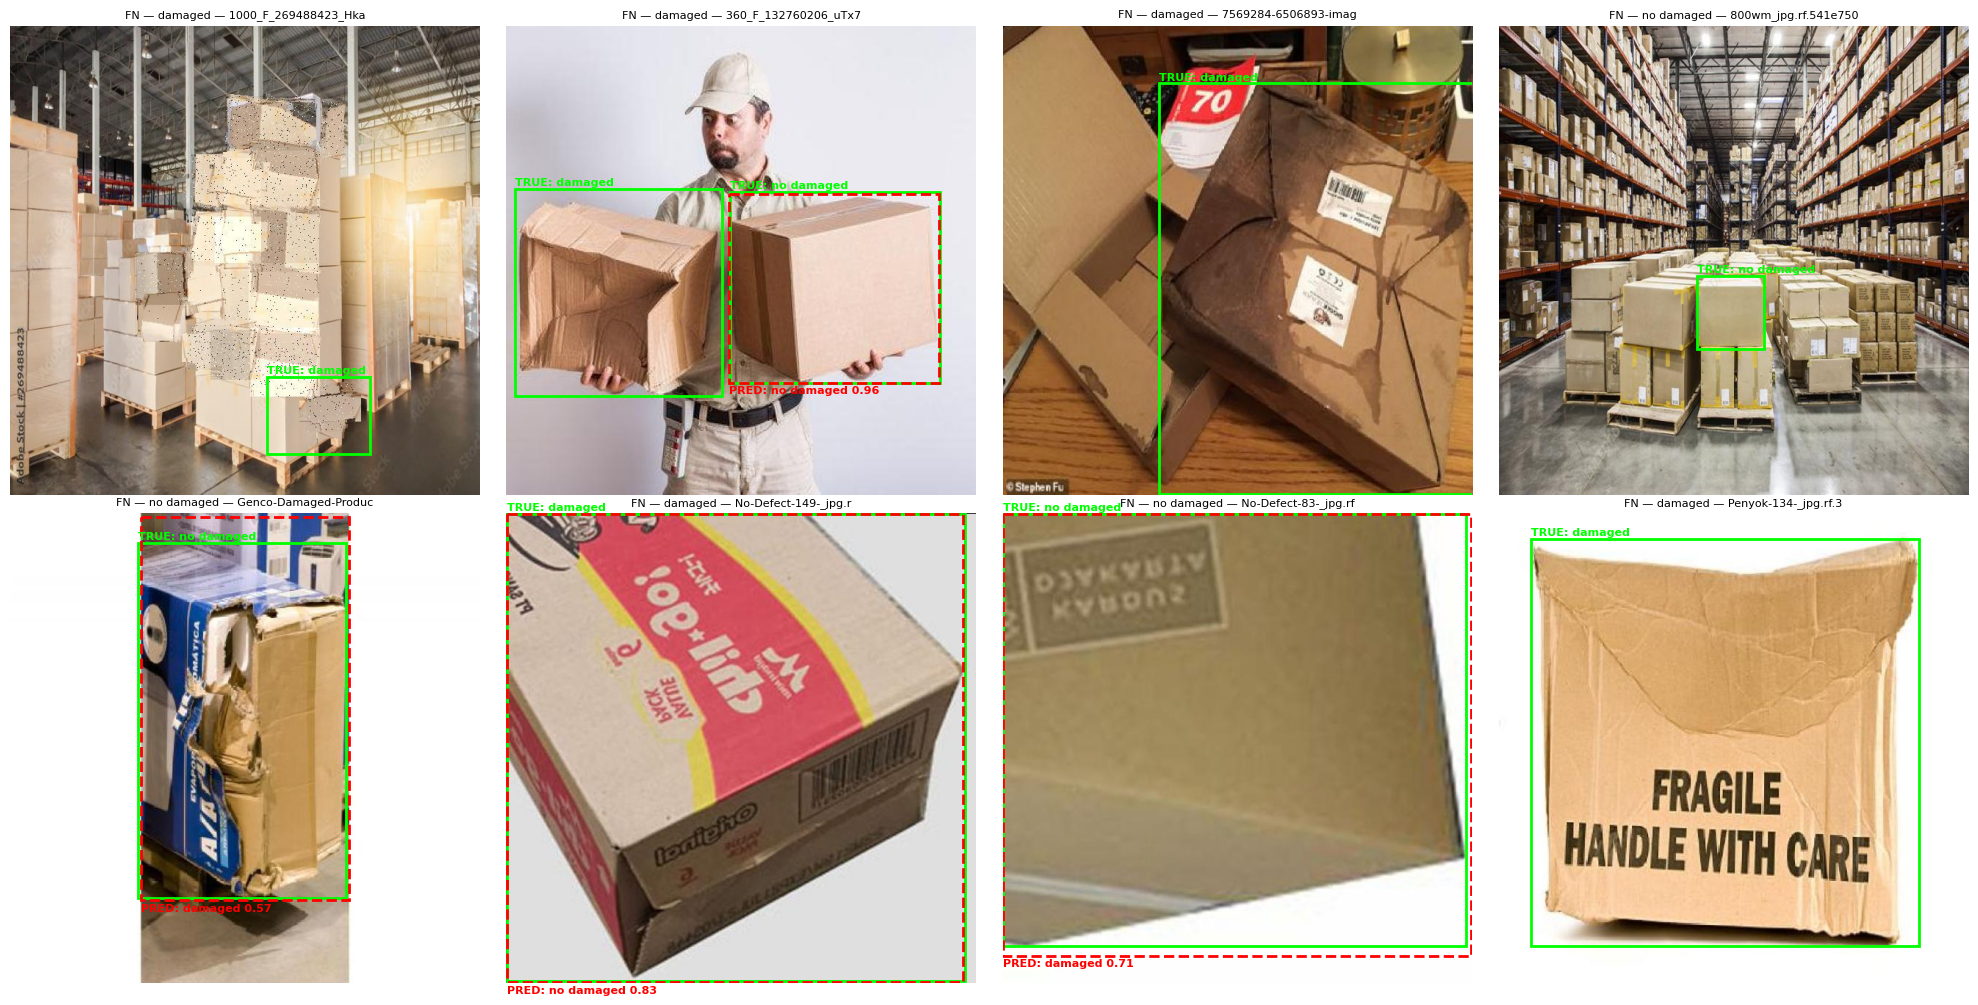

In [153]:
def find_matched_errors(dataset_location, weights_path, class_thresholds, class_names,
                         split='test', iou_thresh=0.5):
    """Per-box (per-instance) error analysis, not per-image.
    Each unmatched ground-truth box counts as its own false negative.
    Each unmatched predicted box counts as its own false positive.
    Matching is greedy: highest-confidence predictions get first pick of
    ground-truth boxes of the same class, and each box (pred or GT) can be
    used in at most one match."""
    from ultralytics import YOLO
    model = YOLO(weights_path)

    img_dir = Path(dataset_location) / split / 'images'
    label_dir = Path(dataset_location) / split / 'labels'
    min_conf = min(class_thresholds.values())

    false_negatives = []  # (image_path, class_id, gt_box)
    false_positives = []  # (image_path, class_id, pred_box, conf)

    for img_path in sorted(img_dir.glob('*')):
        if img_path.suffix.lower() not in ('.jpg', '.jpeg', '.png'):
            continue
        label_path = label_dir / (img_path.stem + '.txt')

        result = model.predict(str(img_path), conf=min_conf, verbose=False)[0]
        img_h, img_w = result.orig_shape
        gt_boxes, gt_classes = load_yolo_labels(label_path, img_w, img_h)

        raw_boxes = result.boxes.xyxy.cpu().numpy().tolist()
        raw_classes = result.boxes.cls.cpu().numpy().astype(int).tolist()
        raw_confs = result.boxes.conf.cpu().numpy().tolist()

        # keep only predictions that clear their own class's best-F1 threshold
        preds = [(b, c, conf) for b, c, conf in zip(raw_boxes, raw_classes, raw_confs)
                 if conf >= class_thresholds.get(c, min_conf)]

        for cls_id in class_thresholds:
            gt_idx = [i for i, c in enumerate(gt_classes) if c == cls_id]
            pred_idx = [i for i, (_, c, _) in enumerate(preds) if c == cls_id]

            gt_matched = set()
            pred_matched = set()

            if gt_idx and pred_idx:
                gt_tensor = torch.tensor([gt_boxes[i] for i in gt_idx])
                pred_tensor = torch.tensor([preds[i][0] for i in pred_idx])
                ious = box_iou(pred_tensor, gt_tensor)  # (n_pred, n_gt)

                # greedy: go through pred-gt pairs by IoU descending
                pairs = [(ious[p, g].item(), p, g) for p in range(len(pred_idx)) for g in range(len(gt_idx))]
                pairs.sort(key=lambda x: -x[0])
                for iou_val, p, g in pairs:
                    if iou_val < iou_thresh:
                        break
                    if p in pred_matched or g in gt_matched:
                        continue
                    pred_matched.add(p)
                    gt_matched.add(g)

            # unmatched GT boxes of this class -> false negatives
            for i, g in enumerate(gt_idx):
                if i not in gt_matched:
                    false_negatives.append((str(img_path), cls_id, gt_boxes[g]))

            # unmatched predicted boxes of this class -> false positives
            for i, p in enumerate(pred_idx):
                if i not in pred_matched:
                    box, _, conf = preds[p]
                    false_positives.append((str(img_path), cls_id, box, conf))

    return false_negatives, false_positives


false_negatives, false_positives = find_matched_errors(
    dataset.location, best_weights_path, best_conf_per_class, CLASS_NAMES, split='test'
)

print(f"False negatives (missed boxes): {len(false_negatives)}")
for i in range(len(CLASS_NAMES)):
    n = sum(1 for _, c, *_ in false_negatives if c == i)
    print(f"  {CLASS_NAMES[i]}: {n}")

print(f"\nFalse positives (extra/wrong boxes): {len(false_positives)}")
for i in range(len(CLASS_NAMES)):
    n = sum(1 for _, c, *_ in false_positives if c == i)
    print(f"  {CLASS_NAMES[i]}: {n}")

test_counts = check_class_balance(dataset.location, 'test')
print("\nCross-check against Section 5 metrics:")
for i, name in enumerate(CLASS_NAMES):
    expected_missed = round((1 - metrics.box.r[i]) * test_counts[i])
    actual_missed = sum(1 for _, c, *_ in false_negatives if c == i)
    print(f"  {name}: recall implies ~{expected_missed} missed instances, found {actual_missed} here")

# 7. Test on Sample Images

This step was listed in your task list but wasn't in the original notebook as a standalone check (your error-analysis cells above are a more advanced version of it). Added here as a quick, literal 'run inference on a handful of images and look at it' cell.

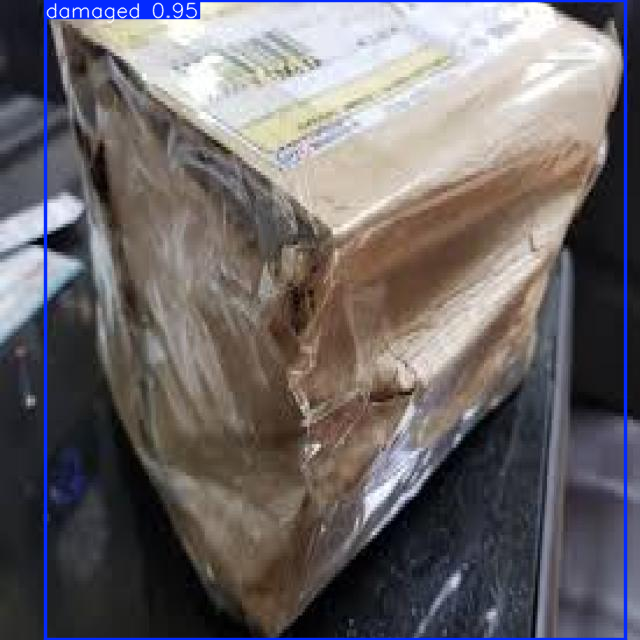

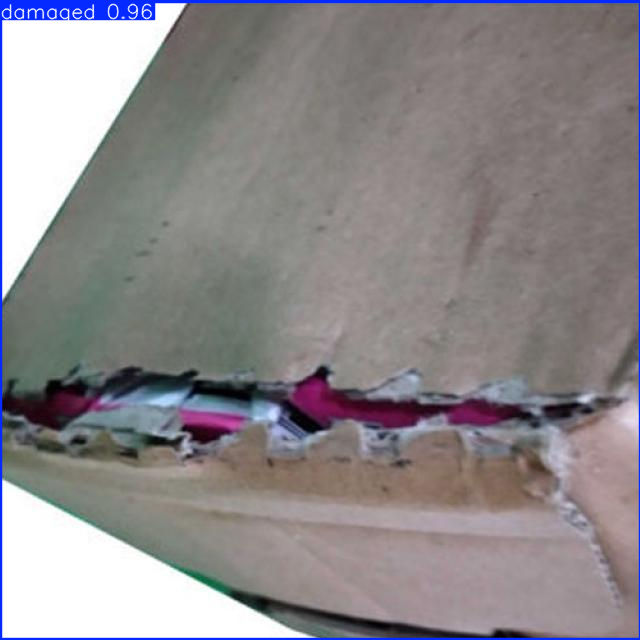

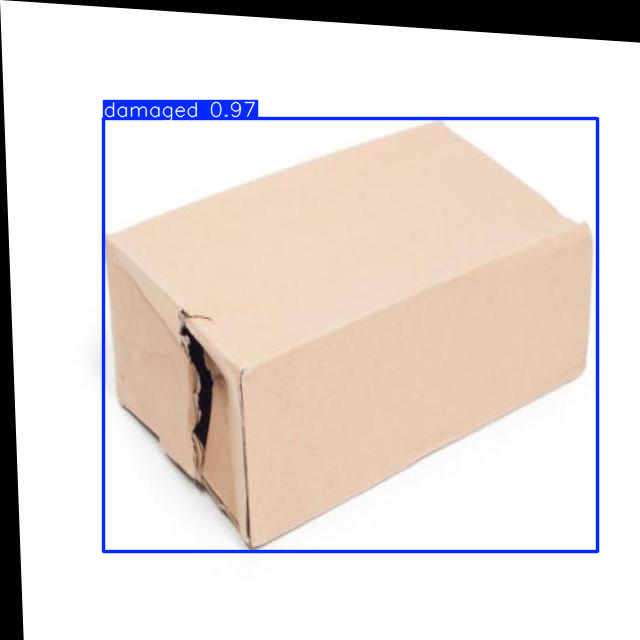

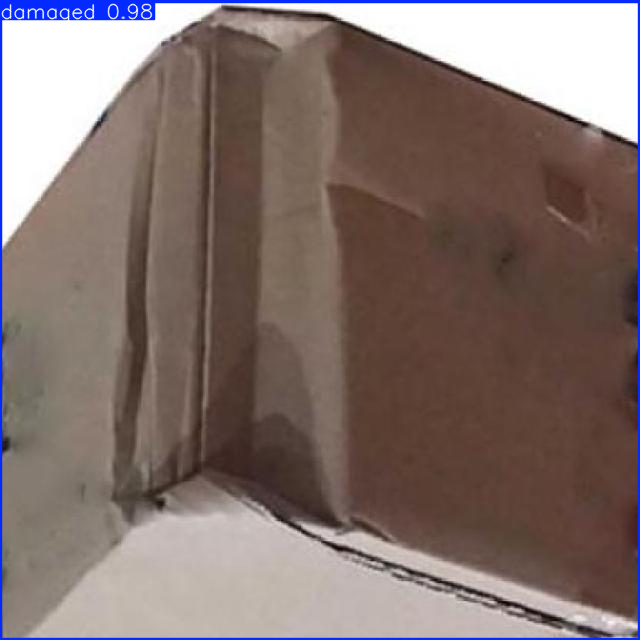

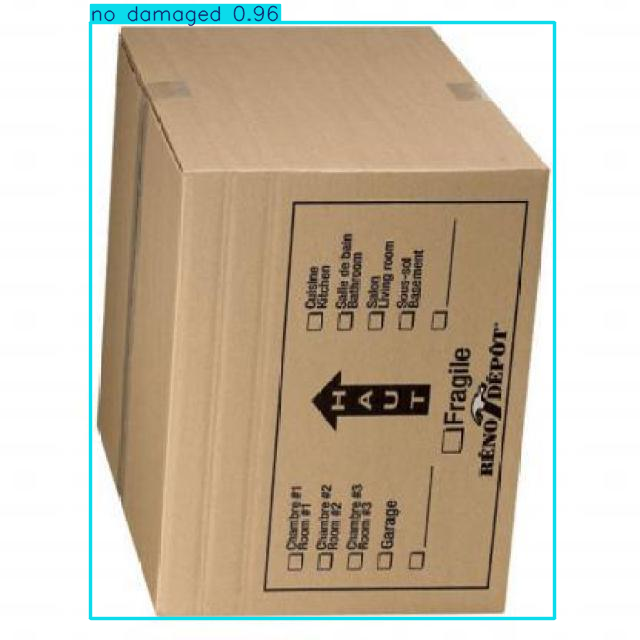

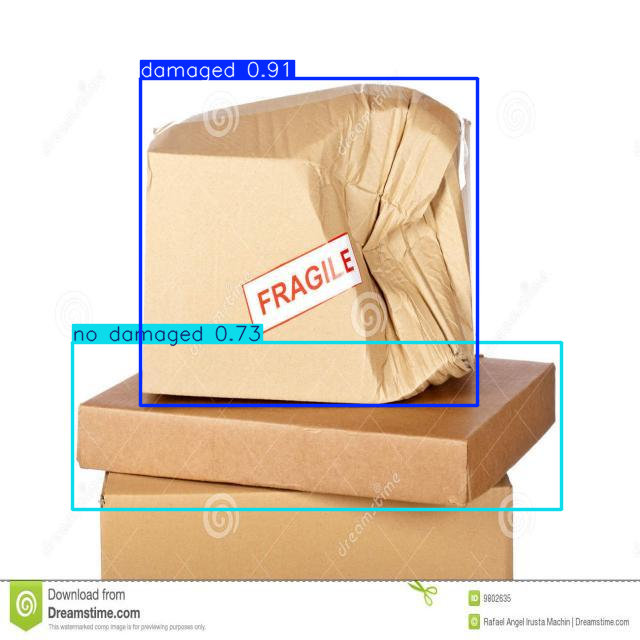

In [159]:

sample_dir = f'{new_location}/test/images'
sample_files = random.sample(os.listdir(sample_dir), k=min(6, len(os.listdir(sample_dir))))

best_model = YOLO(best_weights_path)
for fname in sample_files:
    result = best_model.predict(source=os.path.join(sample_dir, fname), conf=0.5, verbose=False)[0]
    result.show()  # opens/plots the image with predicted boxes drawn on it

# 8. Stock Report

In [158]:
def get_stock_count(weights_path, image_folder, conf_threshold=0.5, iou_threshold=0.5):
    model = YOLO(weights_path)
    results = model.predict(source=image_folder, conf=conf_threshold, iou=iou_threshold, verbose=False)

    counts = {'damaged': 0, 'no damaged': 0}
    detections = []

    for result in results:
        img_h, img_w = result.orig_shape
        for box in result.boxes:
            cls_id = int(box.cls[0].item())
            cls_name = result.names[cls_id]
            counts[cls_name] += 1
            detections.append({'image': result.path, 'class': cls_name,
                                'confidence': round(box.conf[0].item(), 3)})

    report = {'total_damaged': counts['damaged'], 'total_no_damaged': counts['no damaged'],
              'detections': detections}
    with open('stock_report.json', 'w') as f:
        json.dump(report, f, indent=2)
    print(f"Damaged: {counts['damaged']}, No damaged: {counts['no damaged']}")
    return report

report = get_stock_count(best_weights_path, f'{new_location}/test/images')

Damaged: 461, No damaged: 415


# 9. Export Model for Deployment

This was task #6 in your role but was missing from the original notebook — added here. ONNX is the most portable choice if the model will be served behind an API; TorchScript is a fine alternative if the serving stack is pure PyTorch.

In [157]:

best_model = YOLO(best_weights_path)

# ONNX — most portable for deployment (works with ONNX Runtime, many serving frameworks)
onnx_path = best_model.export(format='onnx', imgsz=640, simplify=True)
print(f"Exported ONNX model to: {onnx_path}")

# TorchScript — alternative if you're deploying inside a pure PyTorch service
torchscript_path = best_model.export(format='torchscript', imgsz=640)
print(f"Exported TorchScript model to: {torchscript_path}")

Ultralytics 8.4.146 🚀 Python-3.12.13 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
YOLOv12n summary (fused): 159 layers, 2,557,118 parameters, 0 gradients, 7.3 GFLOPs

PyTorch: starting from '/kaggle/working/runs/detect/yolov12_package/package_detection-7/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 6, 8400) (5.3 MB)

ONNX: starting export with onnx 1.22.0 opset 18...
ONNX: slimming with onnxslim 0.1.96...
ONNX: export success ✅ 2.6s, saved as '/kaggle/working/runs/detect/yolov12_package/package_detection-7/weights/best.onnx' (10.1 MB)

Export complete (3.2s)
Results saved to /kaggle/working/runs/detect/yolov12_package/package_detection-7/weights/best.onnx
Predict:         yolo predict task=detect model=/kaggle/working/runs/detect/yolov12_package/package_detection-7/weights/best.onnx imgsz=640 
Validate:        yolo val task=detect model=/kaggle/working/runs/detect/yolov12_package/package_detection-7/weights/best.onnx imgsz=640 data=/kaggle/workin